## Install Dependencies

In [2]:
%%capture
!pip install transformers sentencepiece sacremoses datasets tqdm matplotlib seaborn pandas numpy

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
BASE   = "/content/drive/MyDrive/indic-translation-asr-project"
PART_C = f"{BASE}/task1_translation_evaluation/part_c_indic_token_behavior"
PLOTS  = f"{PART_C}/plots"
for d in [PART_C, PLOTS, f"{BASE}/data/results/plots"]:
    os.makedirs(d, exist_ok=True)

Mounted at /content/drive


In [5]:
tamil_sentences = [
    "அவன் பள்ளிக்கு போகிறான்.",
    "நான் சாப்பிட்டேன்.",
    "தமிழ் மொழி மிகவும் அழகானது.",
    "அரசியல் சட்டம் மக்களை பாதுகாக்கிறது.",
    "கணினி அறிவியல் படிப்பு மிகவும் சுவாரஸ்யமானது.",
    "செயற்கை நுண்ணறிவு தொழில்நுட்பம் வேகமாக வளர்கிறது.",
    "மருத்துவமனையில் நோயாளிகளுக்கு சிகிச்சை அளிக்கிறார்கள்.",
    "பொருளாதார வளர்ச்சி நாட்டின் முன்னேற்றத்திற்கு அவசியம்.",
    "சுற்றுச்சூழல் பாதுகாப்பு அனைவரின் பொறுப்பு.",
    "தகவல் தொழில்நுட்பத்தில் புதிய கண்டுபிடிப்புகள் வருகின்றன.",
    "அவள் மிகவும் புத்திசாலியான மாணவி.",
    "நம் நாட்டின் பண்பாடு மிகவும் சிறந்தது.",
    "விவசாயிகள் கடினமாக உழைக்கிறார்கள்.",
    "குழந்தைகளுக்கு தரமான கல்வி வழங்க வேண்டும்.",
    "இயற்கை வளங்களை பாதுகாக்க வேண்டும்.",
    "அணுசக்தி மின்சாரம் உற்பத்தி செய்கிறது.",
    "நெடுஞ்சாலை வழியாக பயணம் செய்தோம்.",
    "கலைஞர்களின் படைப்புகள் சமூகத்தை உருவாக்குகின்றன.",
    "திருவள்ளுவர் எழுதிய திருக்குறள் உலகப் புகழ் பெற்றது.",
    "அறிவியல் ஆராய்ச்சி மனித வாழ்வை மேம்படுத்துகிறது.",
]


In [21]:
MODEL_CONFIGS = [
    {"name": "IndicTrans2",  "ckpt": "ai4bharat/indictrans2-en-indic-1B",      "tokenizer_type": "SentencePiece (IndicTrans2)"},
    {"name": "NLLB-200",     "ckpt": "facebook/nllb-200-distilled-600M",       "tokenizer_type": "SentencePiece (NLLB)"},
    {"name": "Helsinki-dra", "ckpt": "Helsinki-NLP/opus-mt-en-dra",            "tokenizer_type": "SentencePiece (Marian)"},
    {"name": "mBART-50",     "ckpt": "facebook/mbart-large-50-many-to-many-mmt","tokenizer_type": "SentencePiece (mBART)"},
    {"name": "MADLAD-400",   "ckpt": "google/madlad400-3b-mt",            "tokenizer_type": "SentencePiece (MADLAD)"},
]

## Load Tokenizers

In [9]:
from transformers import AutoTokenizer

tokenizers = {}
for cfg in MODEL_CONFIGS:
    print(f"Loading {cfg['name']} tokenizer...")
    try:
        tok = AutoTokenizer.from_pretrained(cfg["ckpt"], trust_remote_code=True)
        tokenizers[cfg["name"]] = tok
        print(f"  vocab size: {tok.vocab_size:,}")
    except Exception as e:
        print(f"  ERROR: {e}")
        tokenizers[cfg["name"]] = None

Loading IndicTrans2 tokenizer...
  vocab size: 32,322
Loading NLLB-200 tokenizer...
  vocab size: 256,204
Loading Helsinki-dra tokenizer...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/818k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/1.17M [00:00<?, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/529 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/649 [00:00<?, ?B/s]

  vocab size: 250,054
Loading MADLAD-400 tokenizer...
  vocab size: 256,000


In [29]:
import unicodedata
import numpy as np

def tamil_char(c):
    return 0x0B80 <= ord(c) <= 0x0BFF

def get_token_stats(clean_tokens, n):
    char_lengths        = [len(c) for c in clean_tokens if c]
    avg_chars_per_token = np.mean(char_lengths) if char_lengths else 0
    unicode_frags       = sum(1 for c in clean_tokens if len(c) == 1 and unicodedata.category(c) in ("Mn", "Mc", "Me"))
    short_tokens        = sum(1 for c in clean_tokens if len(c) < 3)
    return {
        "avg_chars_per_token": round(float(avg_chars_per_token), 3),
        "unicode_frag_rate":   round(unicode_frags / n, 4),
        "subword_frag_rate":   round(short_tokens / n, 4),
    }


In [30]:
def indic_metrics(sentence, tokenizer, model_name):
    if tokenizer is None:
        return None

    if model_name == "IndicTrans2":
        processed_sentence = f"tam_Taml tam_Taml {sentence}"
    else:
        processed_sentence = sentence

    enc = tokenizer(processed_sentence, add_special_tokens=False)
    token_ids  = enc["input_ids"]
    token_strs = tokenizer.convert_ids_to_tokens(token_ids)
    n = len(token_strs)
    if n == 0:
        return None

    clean    = [t.lstrip("\u2581").replace("##", "") for t in token_strs]
    stats    = get_token_stats(clean, n)

    unk_id   = tokenizer.unk_token_id
    unk_rate = sum(1 for tid in token_ids if tid == unk_id) / n if unk_id is not None else 0

    tamil_chars    = [c for c in sentence if tamil_char(c)]
    vocab_keys     = set(tokenizer.get_vocab().keys())
    vocab_coverage = sum(1 for c in tamil_chars if any(c in t for t in vocab_keys)) / len(tamil_chars) if tamil_chars else 1.0

    return {
        "model": model_name, "sentence_id": None, "sentence": sentence,
        "token_count": n, **stats,
        "unk_rate": round(unk_rate, 4),
        "vocab_coverage": round(vocab_coverage, 4),
        "memory_bytes": n * 4,
    }

## Run Analysis Across All Models and Sentences

In [31]:
import pandas as pd

rows = []
for cfg in MODEL_CONFIGS:
    name = cfg["name"]
    tok  = tokenizers.get(name)
    for idx, sent in enumerate(tamil_sentences):
        metrics = indic_metrics(sent, tok, name)
        if metrics:
            metrics["sentence_id"] = idx + 1
            rows.append(metrics)

token_df = pd.DataFrame(rows)
token_df.to_csv(f"{PART_C}/tokenization_comparison.csv", index=False)
token_df.to_csv(f"{BASE}/data/results/indic_token_statistics.csv", index=False)

In [32]:
pattern_rows = []
for model_name, grp in token_df.groupby("model"):
    for ptype, fn in [("high_fragmentation", "nlargest"), ("low_fragmentation", "nsmallest")]:
        subset = getattr(grp, fn)(3, "subword_frag_rate")[
            ["sentence_id","sentence","token_count","subword_frag_rate","avg_chars_per_token"]
        ].copy()
        subset["model"]        = model_name
        subset["pattern_type"] = ptype
        pattern_rows.append(subset)

patterns_df = pd.concat(pattern_rows, ignore_index=True)
patterns_df.to_csv(f"{PART_C}/tamil_token_patterns.csv", index=False)
print(patterns_df[patterns_df.pattern_type=="high_fragmentation"][
    ["model","sentence_id","token_count","subword_frag_rate"]
].to_string(index=False))

       model  sentence_id  token_count  subword_frag_rate
Helsinki-dra            2            5             0.6000
Helsinki-dra            1            7             0.5714
Helsinki-dra           13            7             0.5714
 IndicTrans2           10           60             0.9667
 IndicTrans2            7           57             0.9649
 IndicTrans2            8           57             0.9649
  MADLAD-400           11           13             0.6923
  MADLAD-400            6           21             0.6667
  MADLAD-400           13           12             0.6667
    NLLB-200           17           11             0.5455
    NLLB-200            6           15             0.5333
    NLLB-200            7           15             0.5333
    mBART-50           15           10             0.6000
    mBART-50           16           10             0.6000
    mBART-50            9           12             0.5833


## Summary Statistics per Model

In [33]:
results = token_df.groupby("model").agg(
    avg_token_count       = ("token_count","mean"),
    avg_chars_per_token   = ("avg_chars_per_token", "mean"),
    avg_unicode_frag_rate = ("unicode_frag_rate","mean"),
    avg_subword_frag_rate = ("subword_frag_rate","mean"),
    avg_unk_rate          = ("unk_rate","mean"),
    avg_vocab_coverage    = ("vocab_coverage","mean"),
    avg_memory_bytes      = ("memory_bytes","mean"),
).round(4).reset_index()

print(results.to_string(index=False))

       model  avg_token_count  avg_chars_per_token  avg_unicode_frag_rate  avg_subword_frag_rate  avg_unk_rate  avg_vocab_coverage  avg_memory_bytes
Helsinki-dra             9.50               4.2122                 0.0000                 0.5550         0.393                 1.0              38.0
 IndicTrans2            43.35               1.3860                 0.3410                 0.9505         0.000                 1.0             173.4
  MADLAD-400            13.15               2.9023                 0.0478                 0.4969         0.000                 1.0              52.6
    NLLB-200            10.25               3.7311                 0.0205                 0.3426         0.000                 1.0              41.0
    mBART-50             9.80               3.9012                 0.0251                 0.3952         0.000                 1.0              39.2


## Visualisations

/tmp/ipykernel_3931/2887197228.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=MODELS, patch_artist=True)


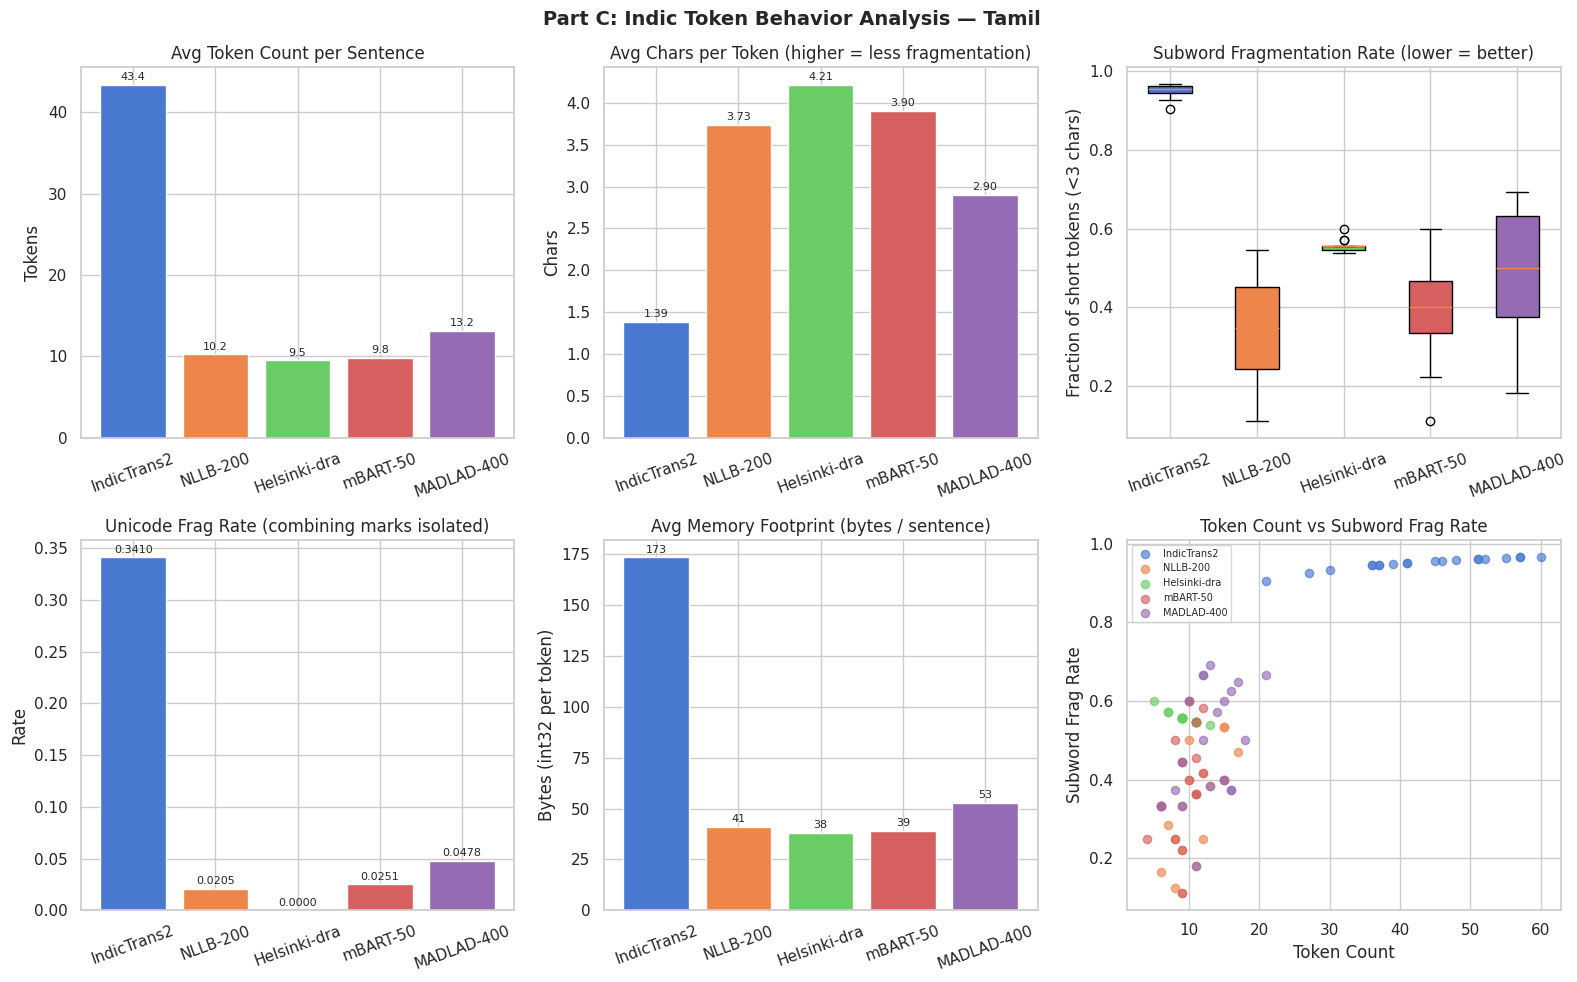

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
MODELS = [c["name"] for c in MODEL_CONFIGS]
colors = sns.color_palette("muted", len(MODELS))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Part C: Indic Token Behavior Analysis — Tamil", fontsize=14, fontweight="bold")

# Avg token count
ax = axes[0, 0]
vals = [results[results.model==m]["avg_token_count"].values[0] for m in MODELS]
bars = ax.bar(MODELS, vals, color=colors)
ax.bar_label(bars, fmt="%.1f", padding=2, fontsize=8)
ax.set_title("Avg Token Count per Sentence")
ax.set_ylabel("Tokens")
ax.tick_params(axis="x", rotation=20)

# Avg chars per token
ax = axes[0, 1]
vals = [results[results.model==m]["avg_chars_per_token"].values[0] for m in MODELS]
bars = ax.bar(MODELS, vals, color=colors)
ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=8)
ax.set_title("Avg Chars per Token (higher = less fragmentation)")
ax.set_ylabel("Chars")
ax.tick_params(axis="x", rotation=20)

# Subword fragmentation rate boxplot
ax = axes[0, 2]
data_box = [token_df[token_df.model==m]["subword_frag_rate"].values for m in MODELS]
bp = ax.boxplot(data_box, labels=MODELS, patch_artist=True)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
ax.set_title("Subword Fragmentation Rate (lower = better)")
ax.set_ylabel("Fraction of short tokens (<3 chars)")
ax.tick_params(axis="x", rotation=20)

# Unicode fragmentation rate
ax = axes[1, 0]
vals = [results[results.model==m]["avg_unicode_frag_rate"].values[0] for m in MODELS]
bars = ax.bar(MODELS, vals, color=colors)
ax.bar_label(bars, fmt="%.4f", padding=2, fontsize=8)
ax.set_title("Unicode Frag Rate (combining marks isolated)")
ax.set_ylabel("Rate")
ax.tick_params(axis="x", rotation=20)

# Memory footprint
ax = axes[1, 1]
vals = [results[results.model==m]["avg_memory_bytes"].values[0] for m in MODELS]
bars = ax.bar(MODELS, vals, color=colors)
ax.bar_label(bars, fmt="%.0f", padding=2, fontsize=8)
ax.set_title("Avg Memory Footprint (bytes / sentence)")
ax.set_ylabel("Bytes (int32 per token)")
ax.tick_params(axis="x", rotation=20)

# token count vs frag rate
ax = axes[1, 2]
for model_name, color in zip(MODELS, colors):
    sub = token_df[token_df.model == model_name]
    ax.scatter(sub["token_count"], sub["subword_frag_rate"],
               label=model_name, alpha=0.65, s=35, color=color)
ax.set_title("Token Count vs Subword Frag Rate")
ax.set_xlabel("Token Count")
ax.set_ylabel("Subword Frag Rate")
ax.legend(fontsize=7)

plt.tight_layout()
for path in [f"{PLOTS}/part_c_token_behavior.png",
             f"{BASE}/data/results/plots/part_c_token_behavior.png"]:
    plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

## Vocabulary Size Comparison

       model              tokenizer_type  vocab_size
 IndicTrans2 SentencePiece (IndicTrans2)       32322
    NLLB-200        SentencePiece (NLLB)      256204
Helsinki-dra      SentencePiece (Marian)       62952
    mBART-50       SentencePiece (mBART)      250054
  MADLAD-400      SentencePiece (MADLAD)      256000


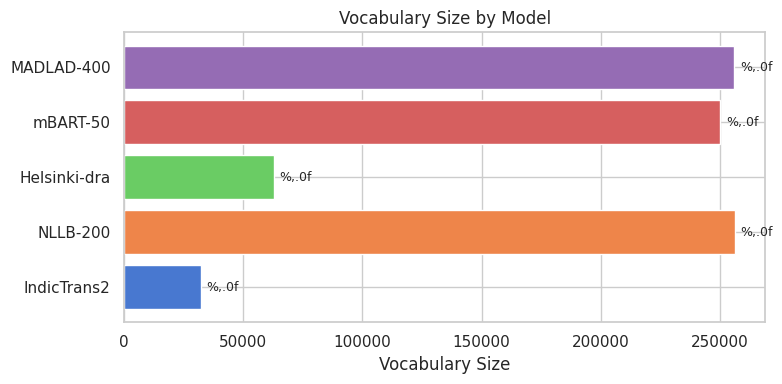

In [35]:
vocab_rows = []
for cfg in MODEL_CONFIGS:
    tok = tokenizers.get(cfg["name"])
    if tok:
        vocab_rows.append({
            "model":          cfg["name"],
            "tokenizer_type": cfg["tokenizer_type"],
            "vocab_size":     tok.vocab_size,
        })

vocab_df = pd.DataFrame(vocab_rows)
print(vocab_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors_v = sns.color_palette("muted", len(vocab_df))
bars = ax.barh(vocab_df["model"], vocab_df["vocab_size"], color=colors_v)
ax.bar_label(bars, fmt="%,.0f", padding=4, fontsize=9)
ax.set_xlabel("Vocabulary Size")
ax.set_title("Vocabulary Size by Model")
plt.tight_layout()
plt.savefig(f"{PLOTS}/part_c_vocab_size.png", dpi=150, bbox_inches="tight")
plt.show()

In [36]:
demo_word = "மருத்துவமனையில்"

print(f"Demo word: {demo_word}\n")
print(f"{'Model':<15} {'#Tokens':<10} Tokens")
for cfg in MODEL_CONFIGS:
    tok = tokenizers.get(cfg["name"])
    if tok:
        # IndicTrans2 requires "src_lang tgt_lang text" format
        input_text = f"tam_Taml tam_Taml {demo_word}" if cfg["name"] == "IndicTrans2" else demo_word
        ids    = tok(input_text, add_special_tokens=False)["input_ids"]
        tokens = tok.convert_ids_to_tokens(ids)
        # Strip the language tag tokens from display (first 2 for IndicTrans2)
        if cfg["name"] == "IndicTrans2":
            tokens = tokens[2:]
        print(f"{cfg['name']:<15} {len(tokens):<10} {' | '.join(tokens)}")

Demo word: மருத்துவமனையில்

Model           #Tokens    Tokens
IndicTrans2     16         ▁ | ம | ர | ு | த | ் | த | ு | வ | ம | ன | ை | ய | ி | ல | ்
NLLB-200        4          ▁மருத்துவ | ம | ன | ையில்
Helsinki-dra    2          ▁ | <unk>
mBART-50        2          ▁மருத்துவமனை | யில்
MADLAD-400      3          ▁மருத்துவ | மன | ையில்
